In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
%matplotlib inline

In [2]:
# Loading the census dataset 
df = pd.read_csv('../data/census-bureau.csv')

In [3]:
# Converting the labels to binary 0/1 for model training

df['label'] = df['label'].str.strip()
df['label'] = df['label'].map({'- 50000.': 0, '50000+.': 1})
print(df['label'].value_counts(normalize=True))

label
0    0.937942
1    0.062058
Name: proportion, dtype: float64


In [4]:
# The weight column tells us how many people in the real population that row represents
# This gives us the TRUE class distribution in the population, not just the sample

total_population = df['weight'].sum()
population_over_50k = df[df['label'] == 1]['weight'].sum()
population_under_50k = df[df['label'] == 0]['weight'].sum()

print(f"Total population represented: {total_population:,.0f}")
print(f"Population earning >50k: {population_over_50k:,.0f} ({population_over_50k/total_population*100:.1f}%)")
print(f"Population earning <50k: {population_under_50k:,.0f} ({population_under_50k/total_population*100:.1f}%)")

Total population represented: 347,245,892
Population earning >50k: 22,241,245 (6.4%)
Population earning <50k: 325,004,647 (93.6%)


Checking for outliers

In [5]:
# Checking for outliers in continuous columns using IQR method

continuous_cols = ['age', 'wage per hour', 'capital gains', 
                   'capital losses', 'dividends from stocks', 'weeks worked in year']

for col in continuous_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    
    print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.1f}%)")

age: 0 outliers (0.0%)
wage per hour: 11304 outliers (5.7%)
capital gains: 7379 outliers (3.7%)
capital losses: 3906 outliers (2.0%)
dividends from stocks: 21141 outliers (10.6%)
weeks worked in year: 0 outliers (0.0%)


Visualize these outliers

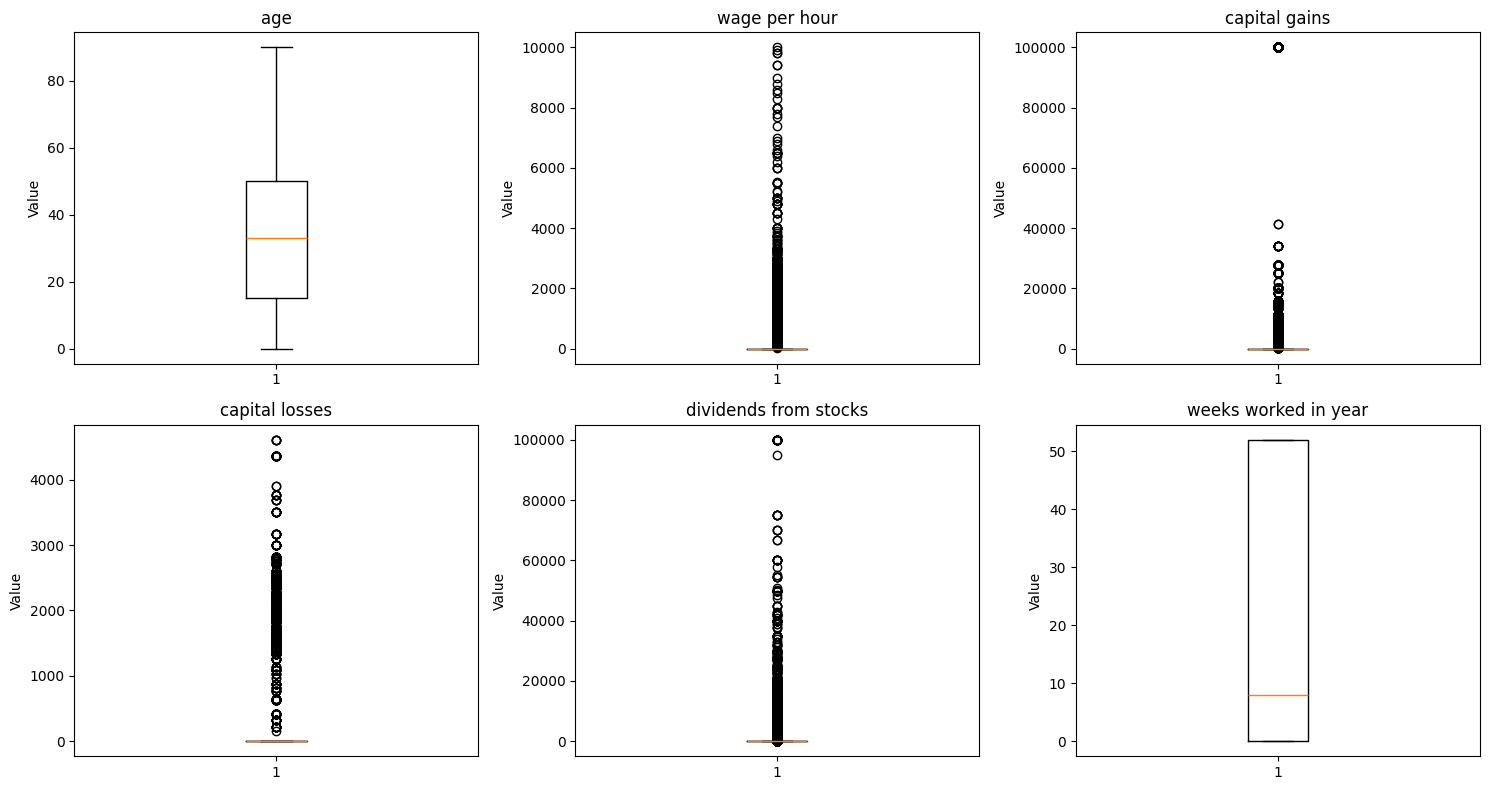

In [9]:
# Visualizing distributions to understand skewness and outlier impact
# This helps decide whether log transformation is needed for LR
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(continuous_cols):
    axes[i].boxplot(df[col])
    axes[i].set_title(col)
    axes[i].set_ylabel('Value')

plt.tight_layout()
plt.savefig('../output/plots/boxplots.png')
plt.show()

In [10]:
# Splitting data into 70/15/15 train/val/test

train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42, stratify=df['label']) # Using stratify to maintain the 6% positive class ratio across all splits
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['label'])

print(f"Train: {train_df.shape}")
print(f"Val: {val_df.shape}")
print(f"Test: {test_df.shape}")

print(f"\nLabel distribution in train: {train_df['label'].value_counts(normalize=True).to_dict()}")
print(f"Label distribution in val: {val_df['label'].value_counts(normalize=True).to_dict()}")
print(f"Label distribution in test: {test_df['label'].value_counts(normalize=True).to_dict()}")

Train: (139666, 42)
Val: (29928, 42)
Test: (29929, 42)

Label distribution in train: {0: 0.9379448111924162, 1: 0.06205518880758381}
Label distribution in val: {0: 0.9379510825982358, 1: 0.062048917401764235}
Label distribution in test: {0: 0.937919743392696, 1: 0.06208025660730395}


In [11]:
# Saving splits so feature_engineering notebook can pick them up directly
# Keeping weight column in all splits for population-weighted evaluation later
train_df.to_csv('../data/train.csv', index=False)
val_df.to_csv('../data/val.csv', index=False)
test_df.to_csv('../data/test.csv', index=False)
print("Train/Val/Test splits saved!")

Train/Val/Test splits saved!
